<a href="https://colab.research.google.com/github/alimugasa/Project/blob/main/CDC_Diabetes_Risk_Factor_Analysis_%7C_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CDC Diabetes Risk Factor Analysis

## Research Question
Which health and lifestyle indicators are most strongly associated with diabetes-related status in this CDC dataset, and what do these relationships suggest for real-world prevention and screening efforts?

## Why this matters
Diabetes is a major public health issue, and early identification of risk patterns can support better screening, prevention, and education strategies. This project uses exploratory data analysis to identify which factors appear most closely linked with diabetes-related status.

## Notebook Roadmap
1. Load and inspect the data  
2. Check data quality  
3. Explore the outcome distribution  
4. Compare BMI by diabetes status  
5. Analyze key binary health indicators  
6. Look at trends across general health and age  
7. Rank the strongest binary indicators  
8. End with real-world applications and actionable insights  

> This is an exploratory analysis, so it shows **association rather than causation**.

In [12]:
!pip -q install ucimlrepo

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from ucimlrepo import fetch_ucirepo

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def md(text):
    display(Markdown(text))

label_map = {
    "HighBP": "High blood pressure",
    "HighChol": "High cholesterol",
    "PhysActivity": "Physical activity",
    "GenHlth": "General health",
    "Age": "Age category",
    "BMI": "BMI",
    "DiffWalk": "Difficulty walking",
    "HeartDiseaseorAttack": "Heart disease or heart attack",
    "Smoker": "Smoking history",
    "Stroke": "Stroke history",
    "CholCheck": "Recent cholesterol check",
    "AnyHealthcare": "Any healthcare coverage",
    "NoDocbcCost": "Could not see doctor due to cost",
    "Fruits": "Fruit consumption",
    "Veggies": "Vegetable consumption",
    "HvyAlcoholConsump": "Heavy alcohol consumption",
    "MentHlth": "Poor mental health days",
    "PhysHlth": "Poor physical health days",
    "Income": "Income level",
    "Education": "Education level",
    "Sex": "Sex"
}

def pretty_name(name):
    return label_map.get(name, name)

def format_list(items):
    items = [str(item) for item in items if str(item).strip()]
    if len(items) == 0:
        return ""
    if len(items) == 1:
        return items[0]
    if len(items) == 2:
        return f"{items[0]} and {items[1]}"
    return ", ".join(items[:-1]) + f", and {items[-1]}"

def add_bar_labels(ax):
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 4),
            textcoords="offset points"
        )

def add_hbar_labels(ax):
    for patch in ax.patches:
        width = patch.get_width()
        ax.annotate(
            f"{width:.1f}",
            (width, patch.get_y() + patch.get_height() / 2),
            ha="left" if width >= 0 else "right",
            va="center",
            fontsize=10,
            xytext=(4 if width >= 0 else -4, 0),
            textcoords="offset points"
        )

In [14]:
# Load the dataset
cdc = fetch_ucirepo(id=891)

X = cdc.data.features.copy()
y = cdc.data.targets.copy()

if isinstance(y, pd.Series):
    y = y.to_frame()

df = pd.concat([X, y], axis=1)

# Use a simple binary target for the analysis
if "Diabetes_binary" in df.columns:
    target = "Diabetes_binary"
    target_note = "0 = no diabetes, 1 = prediabetes or diabetes"
elif "Diabetes_012" in df.columns:
    df["Diabetes_binary"] = (df["Diabetes_012"] > 0).astype(int)
    target = "Diabetes_binary"
    target_note = "Created Diabetes_binary from Diabetes_012: 0 = no diabetes, 1 = prediabetes or diabetes"
else:
    raise ValueError("A diabetes target column was not found.")

display(df.head())

md(
    f"""
### Dataset Loaded

The dataset has been loaded successfully and the analysis will use **`{target}`** as the outcome variable.
Target coding used in this notebook: **{target_note}**.
"""
)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,0,1,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,0,0,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,0,1,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,0,1,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,0,1,0,2,3,0,0,0,11,5,4,0



### Dataset Loaded

The dataset has been loaded successfully and the analysis will use **`Diabetes_binary`** as the outcome variable.  
Target coding used in this notebook: **0 = no diabetes, 1 = prediabetes or diabetes**.


## Data Overview and Quality Checks

This section checks the size of the dataset, confirms the data types, looks for missing values and duplicates, and establishes the overall diabetes-related prevalence that will be used as a baseline throughout the project.

In [15]:
overall_prevalence = df[target].mean() * 100
missing_total = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())

overview = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Target used for analysis",
        "Total missing values",
        "Duplicate rows",
        "Overall diabetes-related prevalence (%)"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        target,
        missing_total,
        duplicate_rows,
        round(overall_prevalence, 2)
    ]
})

column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isna().sum().values
})

display(overview)
display(column_summary)

if missing_total == 0:
    missing_message = "No missing values were found, so no imputation was needed."
else:
    missing_message = f"The dataset contains {missing_total:,} missing values, so summaries use available data."

md(
    f"""
### Interpretation

The dataset contains **{df.shape[0]:,} rows** and **{df.shape[1]} columns**, which is large enough to support stable exploratory patterns.
{missing_message} There are **{duplicate_rows:,} duplicate rows**, which is useful context but not unusual in survey-style datasets.
The overall prevalence of diabetes-related status is **{overall_prevalence:.1f}%**, and that baseline will help us judge which groups are above or below average risk.
"""
)

,Metric,Value
0,Rows,253680
1,Columns,22
2,Target used for analysis,Diabetes_binary
3,Total missing values,0
4,Duplicate rows,24206
5,Overall diabetes-related prevalence (%),13.93


,Column,Data Type,Missing Values
0,HighBP,int64,0
1,HighChol,int64,0
2,CholCheck,int64,0
3,BMI,int64,0
4,Smoker,int64,0
5,Stroke,int64,0
6,HeartDiseaseorAttack,int64,0
7,PhysActivity,int64,0
8,Fruits,int64,0
9,Veggies,int64,0



### Interpretation

The dataset contains **253,680 rows** and **22 columns**, which is large enough to support stable exploratory patterns.  
No missing values were found, so no imputation was needed. There are **24,206 duplicate rows**, which is useful context but not unusual in survey-style datasets.  
The overall prevalence of diabetes-related status is **13.9%**, and that baseline will help us judge which groups are above or below average risk.


## Outcome Distribution

Before comparing health indicators, it is helpful to understand how the diabetes-related target is distributed across the dataset.

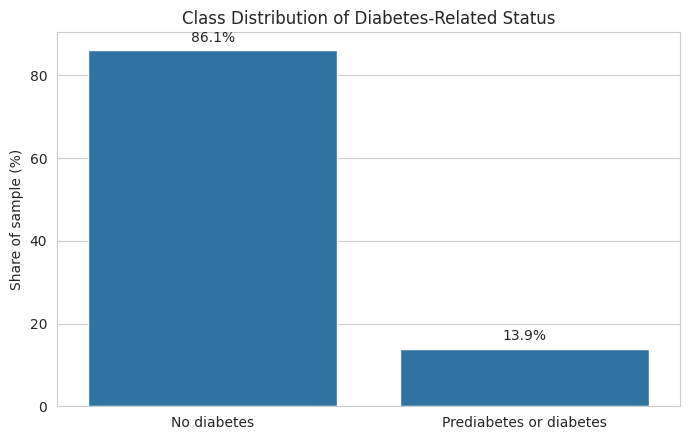


### Interpretation

The larger group in the sample is **No diabetes**, representing **86.1%** of respondents.  
This means the dataset is not perfectly balanced, but it is still very useful for EDA because we can compare each subgroup against the overall baseline of **13.9%**.  
As a result, the next charts focus on whether certain health and lifestyle indicators are associated with noticeably higher diabetes-related prevalence.


In [16]:
class_counts = df[target].value_counts().sort_index()
class_percent = class_counts / class_counts.sum() * 100

plot_df = pd.DataFrame({
    "Status": ["No diabetes", "Prediabetes or diabetes"],
    "Percent": class_percent.values
})

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=plot_df, x="Status", y="Percent")
ax.set_title("Class Distribution of Diabetes-Related Status")
ax.set_xlabel("")
ax.set_ylabel("Share of sample (%)")
add_bar_labels(ax)
plt.tight_layout()
plt.show()

largest_group = plot_df.loc[plot_df["Percent"].idxmax(), "Status"]
largest_share = plot_df["Percent"].max()

md(
    f"""
### Interpretation

The larger group in the sample is **{largest_group}**, representing **{largest_share:.1f}%** of respondents.
This means the dataset is not perfectly balanced, but it is still very useful for EDA because we can compare each subgroup against the overall baseline of **{overall_prevalence:.1f}%**.
As a result, the next charts focus on whether certain health and lifestyle indicators are associated with noticeably higher diabetes-related prevalence.
"""
)

## BMI and Diabetes-Related Status

BMI is one of the most intuitive health indicators in this dataset, so it makes sense to check whether the diabetes-related group has a different BMI distribution from the non-diabetes group.

,mean,median
Diabetes_binary,,
0,27.81,27.00
1,31.94,31.00


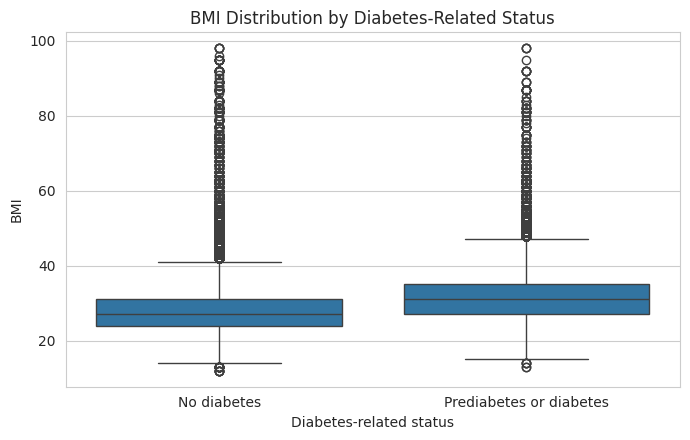


### Interpretation

Respondents with diabetes-related status have a noticeably higher BMI distribution than respondents without it.  
The median BMI increases from **27.00** in the non-diabetes group to **31.00** in the diabetes-related group, and the mean shows the same pattern (**27.81** vs **31.94**).  
This suggests that BMI is one of the clearest continuous indicators associated with diabetes-related status in this dataset, which makes it highly relevant for prevention and screening.


In [17]:
bmi_stats = df.groupby(target)["BMI"].agg(["mean", "median"]).round(2)
display(bmi_stats)

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=df, x=target, y="BMI")
plt.title("BMI Distribution by Diabetes-Related Status")
plt.xlabel("Diabetes-related status")
plt.ylabel("BMI")
plt.xticks([0, 1], ["No diabetes", "Prediabetes or diabetes"])
plt.tight_layout()
plt.show()

mean_no = bmi_stats.loc[0, "mean"]
mean_yes = bmi_stats.loc[1, "mean"]
median_no = bmi_stats.loc[0, "median"]
median_yes = bmi_stats.loc[1, "median"]

md(
    f"""
### Interpretation

Respondents with diabetes-related status have a noticeably higher BMI distribution than respondents without it.
The median BMI increases from **{median_no:.2f}** in the non-diabetes group to **{median_yes:.2f}** in the diabetes-related group, and the mean shows the same pattern (**{mean_no:.2f}** vs **{mean_yes:.2f}**).
This suggests that BMI is one of the clearest continuous indicators associated with diabetes-related status in this dataset, which makes it highly relevant for prevention and screening.
"""
)

## Key Binary Health Indicators

Next, the analysis looks at three practical yes/no indicators that are easy to interpret in real-world settings: high blood pressure, high cholesterol, and physical activity.

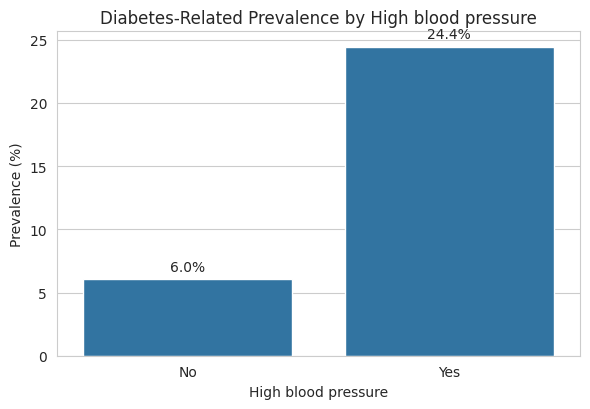


### High blood pressure Interpretation

- Prevalence when `HighBP = 0`: **6.0%**
- Prevalence when `HighBP = 1`: **24.4%**
- When **high blood pressure** is present, diabetes-related prevalence is **18.4 percentage points higher**.

This makes **High blood pressure** a useful screening signal in the dataset, although it still reflects association rather than proof of causation.


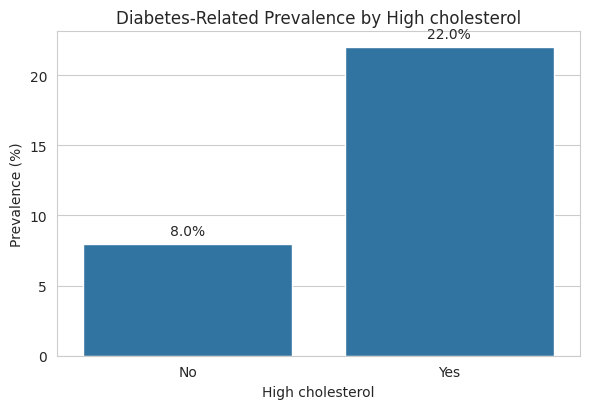


### High cholesterol Interpretation

- Prevalence when `HighChol = 0`: **8.0%**
- Prevalence when `HighChol = 1`: **22.0%**
- When **high cholesterol** is present, diabetes-related prevalence is **14.0 percentage points higher**.

This makes **High cholesterol** a useful screening signal in the dataset, although it still reflects association rather than proof of causation.


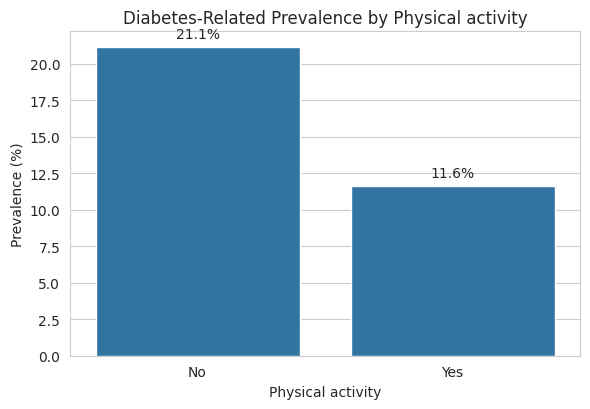


### Physical activity Interpretation

- Prevalence when `PhysActivity = 0`: **21.1%**
- Prevalence when `PhysActivity = 1`: **11.6%**
- When **physical activity** is present, diabetes-related prevalence is **9.5 percentage points lower**.

This makes **Physical activity** a useful screening signal in the dataset, although it still reflects association rather than proof of causation.


In [18]:
def plot_binary_prevalence(feature):
    plot_df = (
        df.groupby(feature)[target]
        .mean()
        .mul(100)
        .reset_index(name="Prevalence")
    )

    plot_df[feature] = plot_df[feature].map({0: "No", 1: "Yes"})

    plt.figure(figsize=(6, 4.2))
    ax = sns.barplot(data=plot_df, x=feature, y="Prevalence")
    ax.set_title(f"Diabetes-Related Prevalence by {pretty_name(feature)}")
    ax.set_xlabel(pretty_name(feature))
    ax.set_ylabel("Prevalence (%)")
    add_bar_labels(ax)
    plt.tight_layout()
    plt.show()

    rate_no = float(plot_df.loc[plot_df[feature] == "No", "Prevalence"].iloc[0])
    rate_yes = float(plot_df.loc[plot_df[feature] == "Yes", "Prevalence"].iloc[0])
    diff = rate_yes - rate_no

    if diff >= 0:
        relationship = f"**{abs(diff):.1f} percentage points higher**"
    else:
        relationship = f"**{abs(diff):.1f} percentage points lower**"

    md(
        f"""
### {pretty_name(feature)} Interpretation

- Prevalence when `{feature} = 0`: **{rate_no:.1f}%**
- Prevalence when `{feature} = 1`: **{rate_yes:.1f}%**
- When **{pretty_name(feature).lower()}** is present, diabetes-related prevalence is {relationship}.

This makes **{pretty_name(feature)}** a useful screening signal in the dataset, although it still reflects association rather than proof of causation.
"""
    )

for feature in ["HighBP", "HighChol", "PhysActivity"]:
    if feature in df.columns:
        plot_binary_prevalence(feature)

## General Health, Age, and Correlation Analysis

This section looks at whether diabetes-related prevalence changes across ordered categories such as general health and age, then uses a correlation heatmap to summarize the broader pattern across important variables.

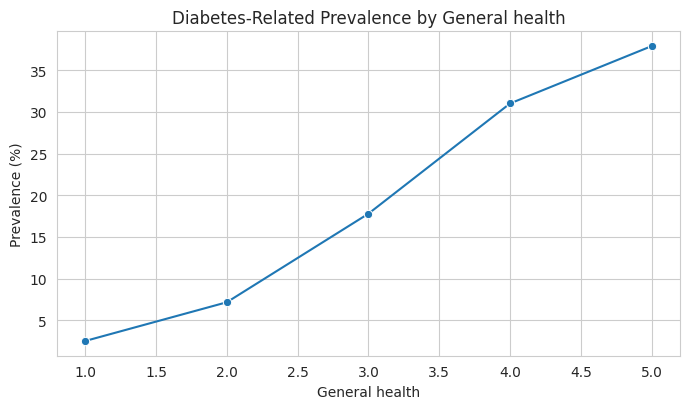


### General health Interpretation

Diabetes-related prevalence changes from **2.5%** in the lowest category to **37.9%** in the highest category.  
This shows a clear gradient, which suggests that **general health** is associated with diabetes-related status in a meaningful way.  
In real-world settings, variables like this are useful because simple survey responses can help identify groups that may need earlier screening or more targeted education.


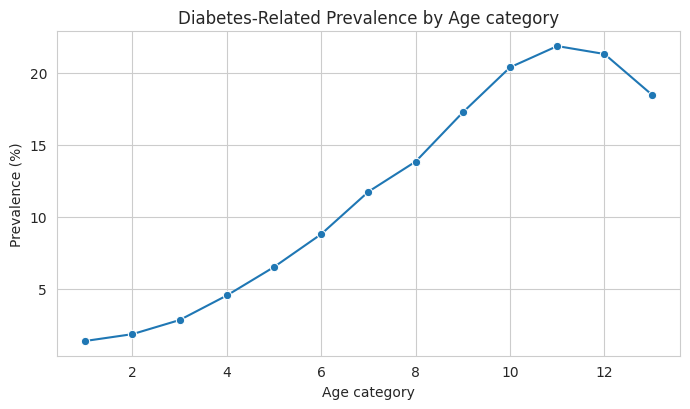


### Age category Interpretation

Diabetes-related prevalence changes from **1.4%** in the lowest category to **18.5%** in the highest category.  
This shows a clear gradient, which suggests that **age category** is associated with diabetes-related status in a meaningful way.  
In real-world settings, variables like this are useful because simple survey responses can help identify groups that may need earlier screening or more targeted education.


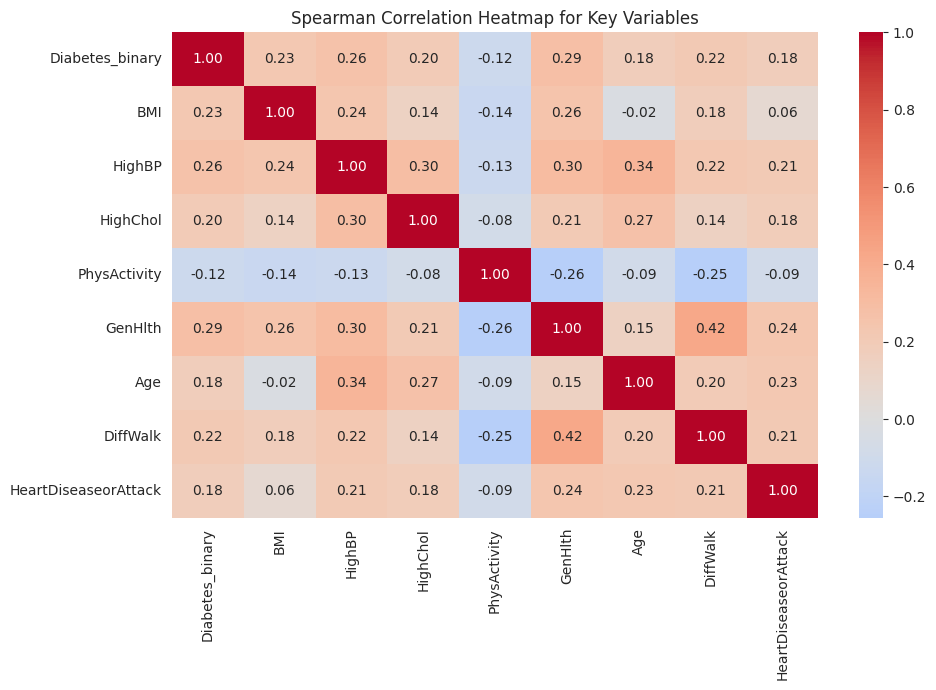


### Correlation Heatmap Interpretation

The strongest monotonic relationships with diabetes-related status in this reduced set are **General health, High blood pressure, and BMI**.  
This supports the earlier charts by showing that diabetes-related status is connected to both cardiometabolic indicators and broader measures of health.  
Because several variables are binary or ordinal survey variables, the heatmap should be interpreted as a summary of association rather than a causal ranking.


In [19]:
for feature in ["GenHlth", "Age"]:
    if feature in df.columns:
        trend_df = (
            df.groupby(feature)[target]
            .mean()
            .mul(100)
            .reset_index(name="Prevalence")
        )

        plt.figure(figsize=(7, 4.2))
        sns.lineplot(data=trend_df, x=feature, y="Prevalence", marker="o")
        plt.title(f"Diabetes-Related Prevalence by {pretty_name(feature)}")
        plt.xlabel(pretty_name(feature))
        plt.ylabel("Prevalence (%)")
        plt.tight_layout()
        plt.show()

        start_rate = float(trend_df["Prevalence"].iloc[0])
        end_rate = float(trend_df["Prevalence"].iloc[-1])

        md(
            f"""
### {pretty_name(feature)} Interpretation

Diabetes-related prevalence changes from **{start_rate:.1f}%** in the lowest category to **{end_rate:.1f}%** in the highest category.
This shows a clear gradient, which suggests that **{pretty_name(feature).lower()}** is associated with diabetes-related status in a meaningful way.
In real-world settings, variables like this are useful because simple survey responses can help identify groups that may need earlier screening or more targeted education.
"""
        )

heatmap_cols = [
    target, "BMI", "HighBP", "HighChol", "PhysActivity",
    "GenHlth", "Age", "DiffWalk", "HeartDiseaseorAttack"
]
heatmap_cols = [col for col in heatmap_cols if col in df.columns]

corr = df[heatmap_cols].corr(method="spearman")

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman Correlation Heatmap for Key Variables")
plt.tight_layout()
plt.show()

top_corr = corr[target].drop(target).abs().sort_values(ascending=False).head(3)
top_corr_features = [pretty_name(col) for col in top_corr.index]

md(
    f"""
### Correlation Heatmap Interpretation

The strongest monotonic relationships with diabetes-related status in this reduced set are **{format_list(top_corr_features)}**.
This supports the earlier charts by showing that diabetes-related status is connected to both cardiometabolic indicators and broader measures of health.
Because several variables are binary or ordinal survey variables, the heatmap should be interpreted as a summary of association rather than a causal ranking.
"""
)

## Ranked Comparison of the Strongest Indicators

To make the findings easier to explain, this section ranks all binary indicators by the size of their prevalence difference. This helps identify the strongest practical screening signals in the dataset.

,Indicator,Prevalence when 1 (%),Prevalence when 0 (%),Difference (pp),Prevalence ratio
5,Heart disease or heart attack,32.97,11.95,21.02,2.76
12,Difficulty walking,30.75,10.53,20.21,2.92
4,Stroke history,31.75,13.18,18.57,2.41
0,High blood pressure,24.45,6.04,18.41,4.05
1,High cholesterol,22.01,7.98,14.03,2.76


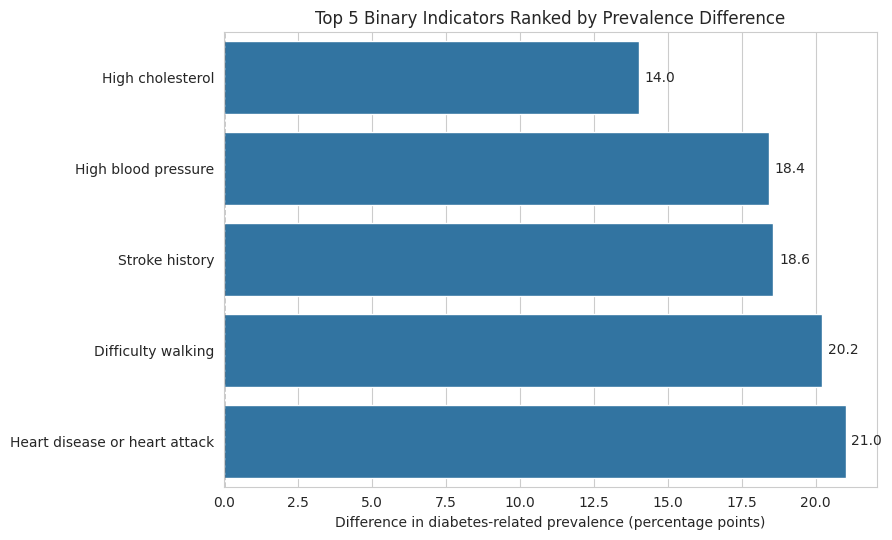


## Real-World Applications

- **Targeted screening:** People with **Heart disease or heart attack, Difficulty walking, and Stroke history** show meaningfully higher diabetes-related prevalence, so these indicators could help prioritize earlier glucose screening.
- **Lifestyle intervention:** Median BMI rises from **27.00** in the non-diabetes group to **31.00** in the diabetes-related group. This supports the value of weight-management and physical activity programs in prevention efforts.
- **Public health education:** General health shows a clear gradient, with prevalence moving from **2.5%** in the lowest category to **37.9%** in the highest category. Age also matters, with prevalence increasing from **1.4%** in the lowest category to **18.5%** in the highest category.
- **Resource allocation:** The ranking table helps focus outreach on groups whose prevalence is well above the overall baseline of **13.9%**.

## Conclusion and Actionable Insights

- The overall diabetes-related prevalence in this dataset is **13.9%**.
- **Heart disease or heart attack** is the strongest binary indicator in this analysis, with a **21.0 percentage-point** difference between groups.
- BMI is clearly higher in the diabetes-related group, which makes it one of the strongest continuous indicators in the dataset.
- Higher-risk patterns appear across both clinical-style indicators and broader self-reported health measures.
- In practice, these findings support earlier screening, more targeted prevention outreach, and better use of limited public health resources.

**Limitations:** This is an observational EDA project, so the results show **association rather than causation**. Some variables are survey-based, which means self-report bias may affect the results.

**Next step:** A useful next step would be to compare prediabetes and diabetes separately, or repeat the analysis by subgroup such as age or sex.


In [20]:
binary_candidates = [
    col for col in df.columns
    if col != target and set(df[col].dropna().unique()).issubset({0, 1})
]

rows = []

for col in binary_candidates:
    prevalence = df.groupby(col)[target].mean().mul(100)

    if 0 in prevalence.index and 1 in prevalence.index:
        rate_0 = float(prevalence.loc[0])
        rate_1 = float(prevalence.loc[1])
        diff = rate_1 - rate_0
        ratio = np.nan if rate_0 == 0 else rate_1 / rate_0

        rows.append({
            "Indicator": pretty_name(col),
            "Prevalence when 1 (%)": rate_1,
            "Prevalence when 0 (%)": rate_0,
            "Difference (pp)": diff,
            "Prevalence ratio": ratio
        })

binary_results = pd.DataFrame(rows)
binary_results["Absolute difference"] = binary_results["Difference (pp)"].abs()
top5 = binary_results.sort_values("Absolute difference", ascending=False).head(5).copy()

display(
    top5[["Indicator", "Prevalence when 1 (%)", "Prevalence when 0 (%)", "Difference (pp)", "Prevalence ratio"]]
)

plot_df = top5.sort_values("Difference (pp)")

plt.figure(figsize=(9, 5.5))
ax = sns.barplot(data=plot_df, y="Indicator", x="Difference (pp)", orient="h")
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Top 5 Binary Indicators Ranked by Prevalence Difference")
ax.set_xlabel("Difference in diabetes-related prevalence (percentage points)")
ax.set_ylabel("")
add_hbar_labels(ax)
plt.tight_layout()
plt.show()

best_indicator = top5.iloc[0]["Indicator"]
best_diff = top5.iloc[0]["Difference (pp)"]

top_positive = top5[top5["Difference (pp)"] > 0]["Indicator"].tolist()
top_positive_text = format_list(top_positive[:3])

genhlth_text = ""
if "GenHlth" in df.columns:
    genhlth_trend = df.groupby("GenHlth")[target].mean().mul(100)
    genhlth_text = (
        f"General health shows a clear gradient, with prevalence moving from **{genhlth_trend.iloc[0]:.1f}%** "
        f"in the lowest category to **{genhlth_trend.iloc[-1]:.1f}%** in the highest category."
    )

age_text = ""
if "Age" in df.columns:
    age_trend = df.groupby("Age")[target].mean().mul(100)
    age_text = (
        f"Age also matters, with prevalence increasing from **{age_trend.iloc[0]:.1f}%** "
        f"in the lowest category to **{age_trend.iloc[-1]:.1f}%** in the highest category."
    )

bmi_text = (
    f"Median BMI rises from **{median_no:.2f}** in the non-diabetes group to **{median_yes:.2f}** "
    f"in the diabetes-related group."
)

md(
    f"""
## Real-World Applications

- **Targeted screening:** People with **{top_positive_text}** show meaningfully higher diabetes-related prevalence, so these indicators could help prioritize earlier glucose screening.
- **Lifestyle intervention:** {bmi_text} This supports the value of weight-management and physical activity programs in prevention efforts.
- **Public health education:** {genhlth_text} {age_text}
- **Resource allocation:** The ranking table helps focus outreach on groups whose prevalence is well above the overall baseline of **{overall_prevalence:.1f}%**.

## Conclusion and Actionable Insights

- The overall diabetes-related prevalence in this dataset is **{overall_prevalence:.1f}%**.
- **{best_indicator}** is the strongest binary indicator in this analysis, with a **{abs(best_diff):.1f} percentage-point** difference between groups.
- BMI is clearly higher in the diabetes-related group, which makes it one of the strongest continuous indicators in the dataset.
- Higher-risk patterns appear across both clinical-style indicators and broader self-reported health measures.
- In practice, these findings support earlier screening, more targeted prevention outreach, and better use of limited public health resources.

**Limitations:** This is an observational EDA project, so the results show **association rather than causation**. Some variables are survey-based, which means self-report bias may affect the results.

**Next step:** A useful next step would be to compare prediabetes and diabetes separately, or repeat the analysis by subgroup such as age or sex.
"""
)